# K-Means Clustering: Fundamentos y Aplicación Práctica

## 1. Introducción
liga: https://gamma.app/docs/K-Means-Clustering-szlr5ng75u1p9uk?mode=doc

El K-Means Clustering es uno de los algoritmos de aprendizaje no supervisado más populares y ampliamente utilizados. Este método permite agrupar datos en un número predefinido de clusters (K), donde cada punto de datos pertenece al cluster con el centroide más cercano.

En este notebook, exploraremos:
- Los fundamentos teóricos del algoritmo K-Means
- La distancia euclidiana como medida de similitud
- El coeficiente de silueta como métrica de evaluación
- Una implementación práctica con visualizaciones

## 2. Fundamentos Teóricos de K-Means

### 2.1 El Algoritmo K-Means

K-Means es un algoritmo iterativo que sigue estos pasos:

1. **Inicialización**: Seleccionar aleatoriamente K puntos como centroides iniciales.
2. **Asignación**: Asignar cada punto de datos al centroide más cercano.
3. **Actualización**: Recalcular los centroides como el promedio de todos los puntos asignados a cada cluster.
4. **Iteración**: Repetir los pasos 2 y 3 hasta que los centroides se estabilicen o se alcance un número máximo de iteraciones.

In [1]:
# Importamos las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm

# Configuración para visualizaciones
# Usamos un estilo válido de matplotlib en lugar de 'seaborn'
plt.style.use('ggplot')  # Alternativas: 'default', 'classic', 'bmh', 'fivethirtyeight'
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

## 3. Generación de Datos para Clustering

Para nuestro ejemplo, vamos a generar un conjunto de datos que sea ideal para visualizar el clustering. Utilizaremos la función `make_blobs` de scikit-learn.

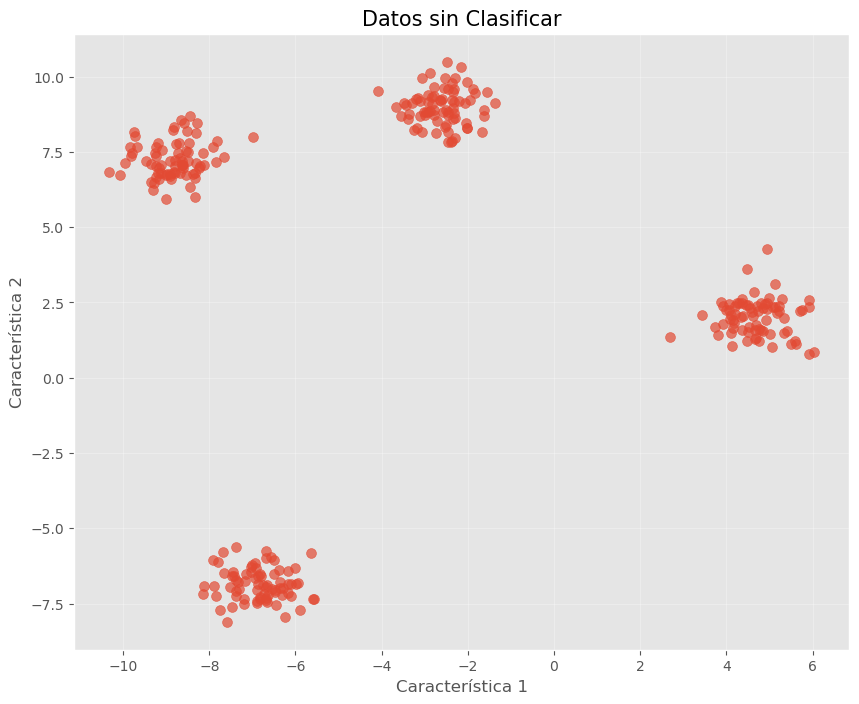

In [2]:
# Generamos datos sintéticos con estructura de clusters
X, y_true = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.60,
    random_state=42
)

# Visualizamos los datos sin etiquetar
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], s=50, alpha=0.7)
plt.title('Datos sin Clasificar', fontsize=15)
plt.xlabel('Característica 1', fontsize=12)
plt.ylabel('Característica 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


## 4. Aplicación del Algoritmo K-Means

Ahora aplicaremos el algoritmo K-Means a nuestros datos.

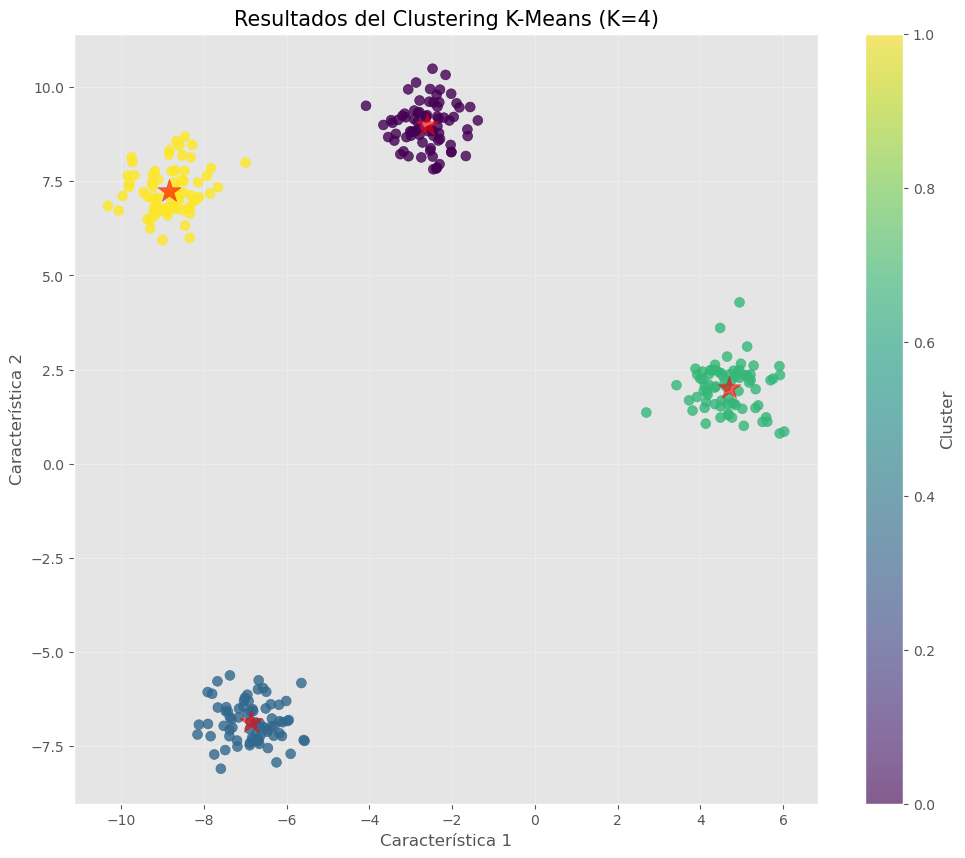

In [ ]:
# Implementación del algoritmo K-Means
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10,
  )

y_pred = kmeans.fit_predict(X)

# Obtenemos los centroides
centroides = kmeans.cluster_centers_

# Visualizamos los resultados
plt.figure(figsize=(12, 10))

# Graficamos los puntos coloreados por cluster
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=50, cmap='viridis', alpha=0.8)

# Graficamos los centroides
plt.scatter(centroides[:, 0], centroides[:, 1], c='red', s=300, alpha=0.6, marker='*')

plt.title('Resultados del Clustering K-Means (K=4)', fontsize=15)
plt.xlabel('Característica 1', fontsize=12)
plt.ylabel('Característica 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.colorbar(label='Cluster')
plt.show()

## 5. Determinando el Número Óptimo de Clusters

Uno de los desafíos en K-Means es determinar el número óptimo de clusters (K). Existen varios métodos para esto, y uno de los más comunes es el método del codo (Elbow Method).

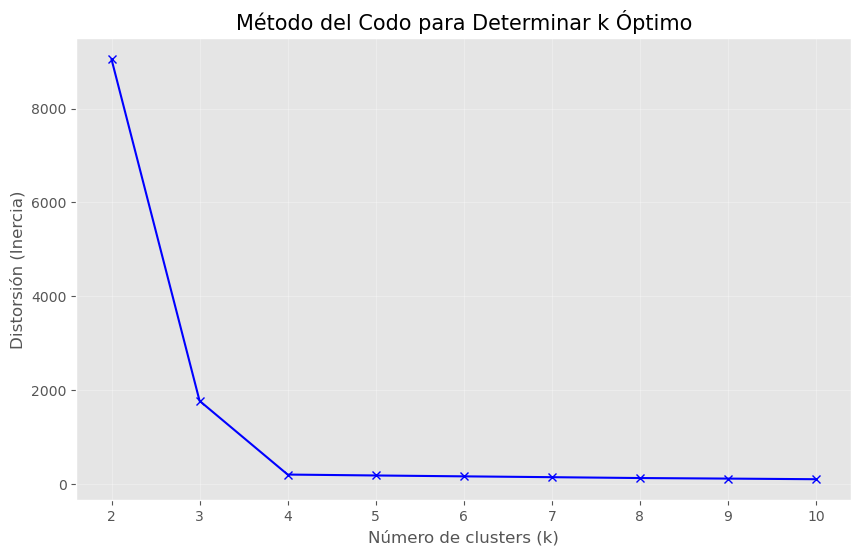

In [10]:
# Método del codo para determinar el número óptimo de clusters
def metodo_del_codo(X, rango_k=range(2, 11)):
    distorsiones = []

    for k in rango_k:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        distorsiones.append(kmeans.inertia_)

    # Gráfica del método del codo
    plt.figure(figsize=(10, 6))
    plt.plot(rango_k, distorsiones, 'bx-')
    plt.xlabel('Número de clusters (k)', fontsize=12)
    plt.ylabel('Distorsión (Inercia)', fontsize=12)
    plt.title('Método del Codo para Determinar k Óptimo', fontsize=15)
    plt.grid(True, alpha=0.3)
    plt.show()

# Aplicamos el método del codo
metodo_del_codo(X)

## 6. Coeficiente de Silueta

El coeficiente de silueta es una métrica que mide qué tan similar es un objeto a su propio cluster (cohesión) en comparación con otros clusters (separación). El rango de valores está entre -1 y 1:
- Valores cercanos a 1 indican que el punto está bien agrupado.
- Valores cercanos a 0 indican que el punto está en la frontera entre dos clusters.
- Valores cercanos a -1 indican que el punto probablemente esté asignado al cluster incorrecto.

El coeficiente de silueta se calcula como:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

Donde:
- $a(i)$ es la distancia media entre el punto $i$ y todos los demás puntos en el mismo cluster.
- $b(i)$ es la distancia media entre el punto $i$ y todos los puntos del cluster más cercano al que no pertenece.

### 6.1 Cálculo del Coeficiente de Silueta

Para k = 2, el coeficiente de silueta promedio es: 0.615


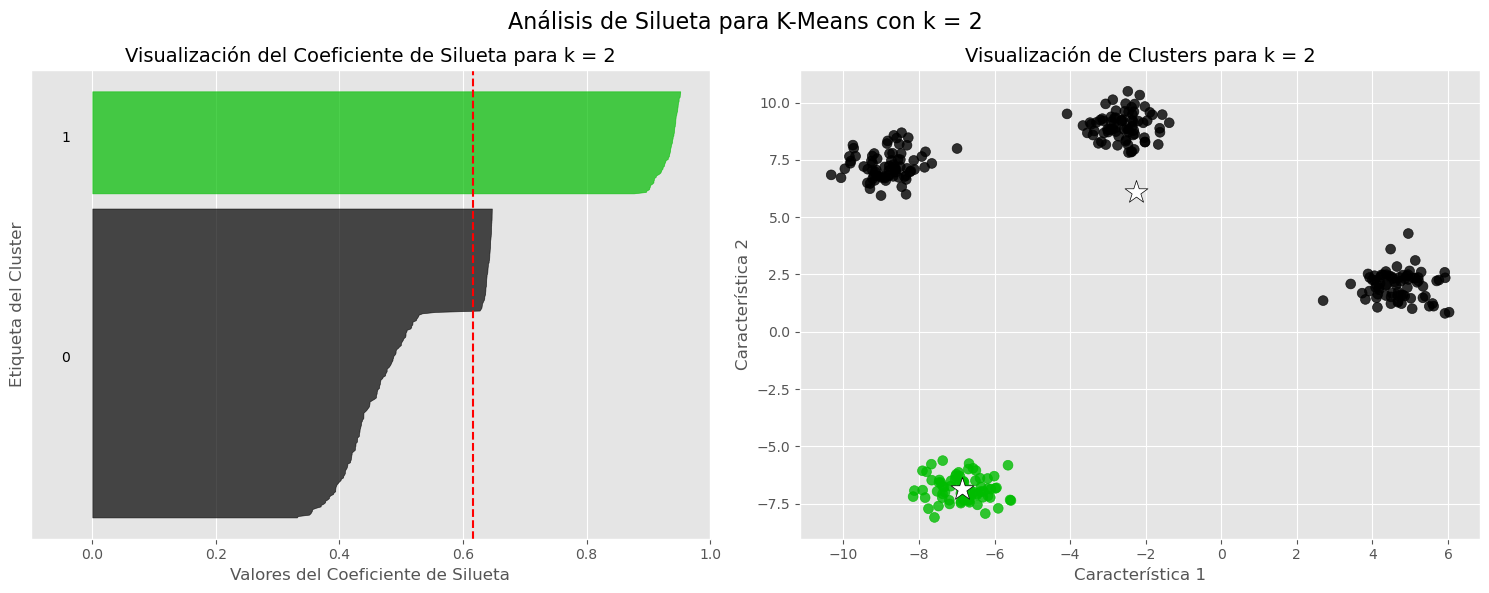

Para k = 3, el coeficiente de silueta promedio es: 0.799


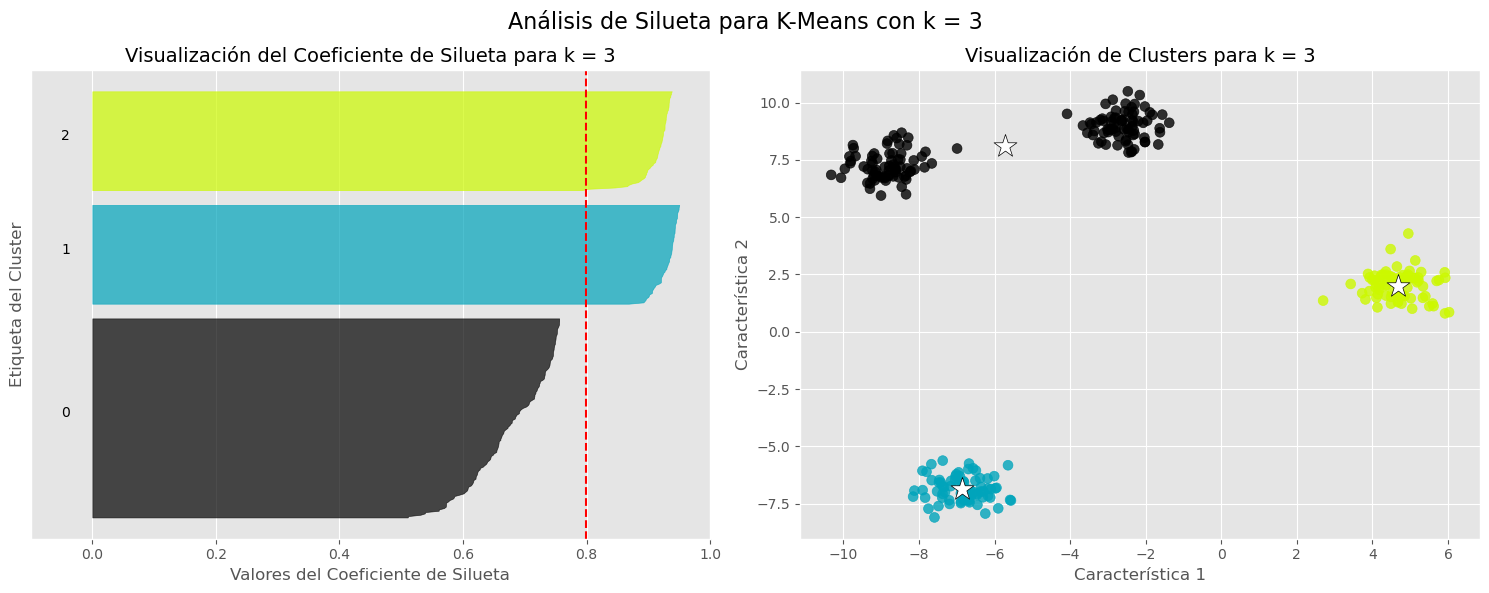

Para k = 4, el coeficiente de silueta promedio es: 0.876


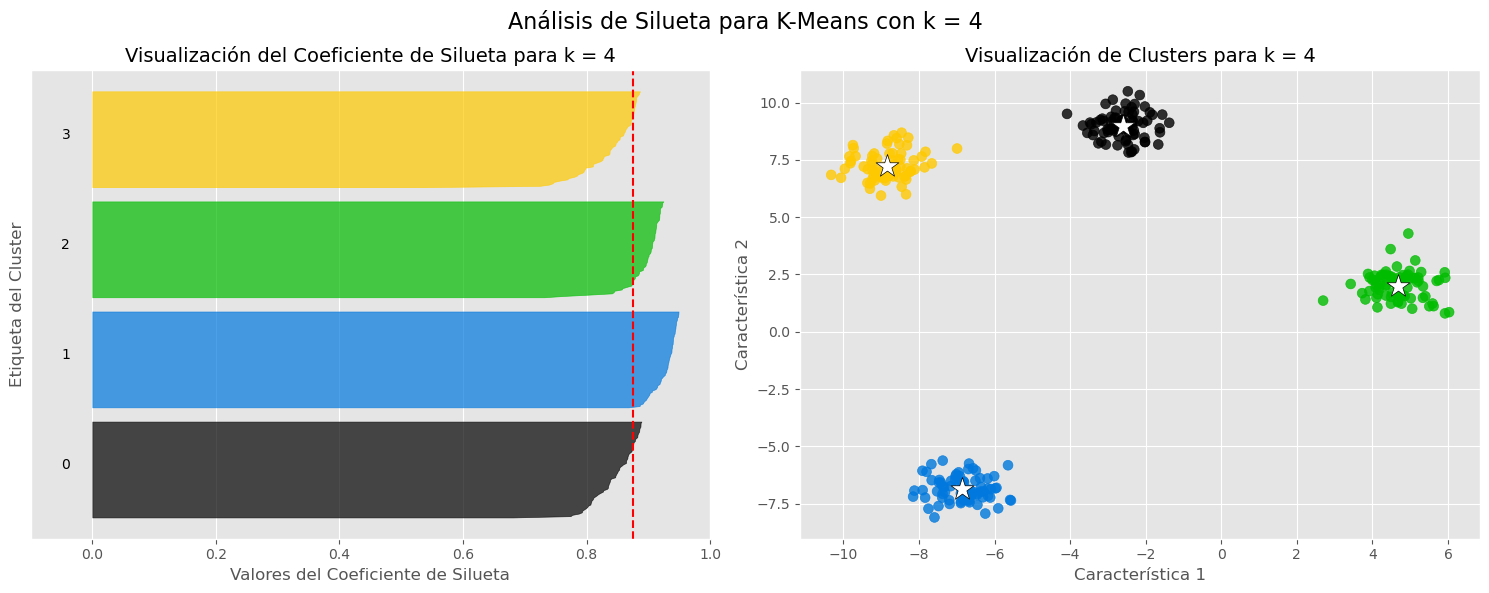

Para k = 5, el coeficiente de silueta promedio es: 0.755


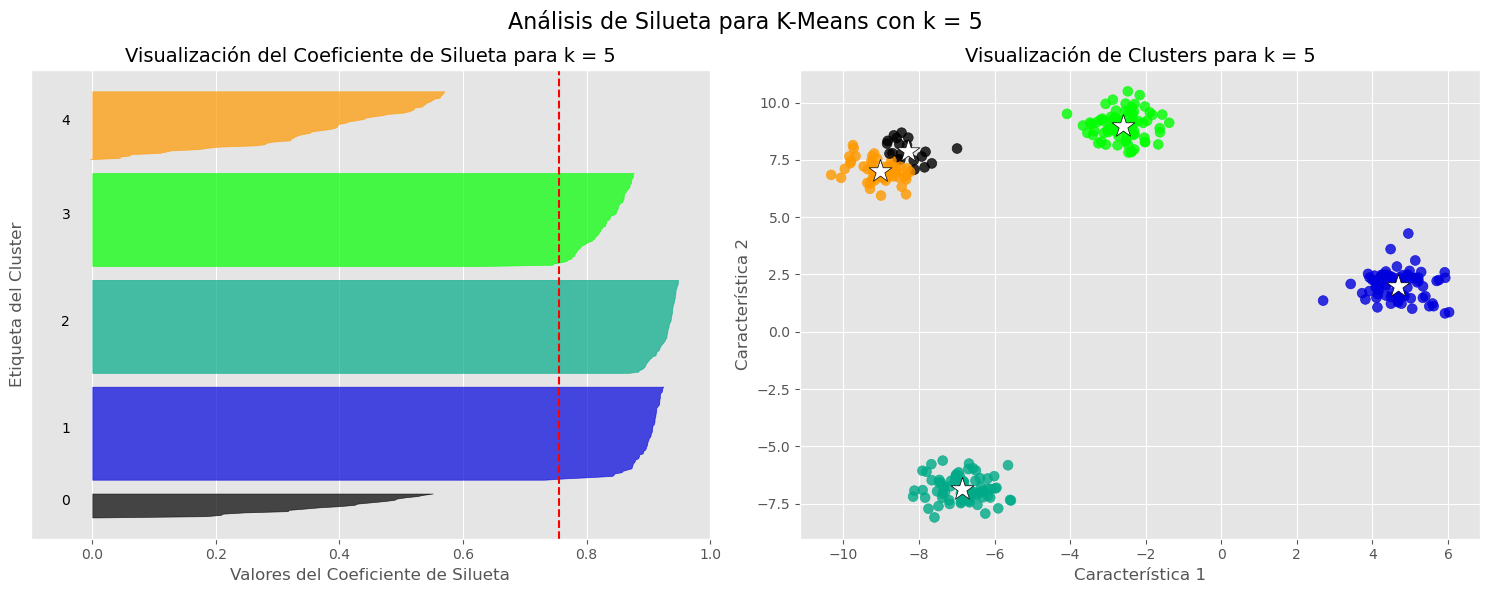

In [5]:
# Función para visualizar el coeficiente de silueta
def visualizar_silueta(X, rango_k=range(2, 6)):
    for k in rango_k:
        # Creamos el subplot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # Ajustamos K-Means
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(X)

        # Calculamos el coeficiente de silueta para cada muestra
        silhouette_avg = silhouette_score(X, cluster_labels)
        silhouette_values = silhouette_samples(X, cluster_labels)

        # Gráfico de silueta
        y_lower = 10
        for i in range(k):
            # Obtenemos las siluetas para este cluster
            ith_cluster_silhouette_values = silhouette_values[cluster_labels == i]
            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / k)
            ax1.fill_betweenx(np.arange(y_lower, y_upper),
                             0, ith_cluster_silhouette_values,
                             facecolor=color, edgecolor=color, alpha=0.7)

            # Etiquetamos los clusters
            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

            # Calculamos el nuevo y_lower para el siguiente gráfico
            y_lower = y_upper + 10

        # La línea vertical del valor medio de silueta
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
        ax1.set_title(f"Visualización del Coeficiente de Silueta para k = {k}", fontsize=14)
        ax1.set_xlabel("Valores del Coeficiente de Silueta", fontsize=12)
        ax1.set_ylabel("Etiqueta del Cluster", fontsize=12)
        ax1.set_yticks([])  # Limpiar el eje y
        ax1.set_xlim([-0.1, 1])

        # Gráfico de clusters
        colors = cm.nipy_spectral(cluster_labels.astype(float) / k)
        ax2.scatter(X[:, 0], X[:, 1], marker='o', s=50, c=colors, alpha=0.8)

        # Gráfico de centroides
        centroides = kmeans.cluster_centers_
        ax2.scatter(centroides[:, 0], centroides[:, 1], marker='*', c='white',
                   s=300, alpha=1, edgecolor='k')

        ax2.set_title(f"Visualización de Clusters para k = {k}", fontsize=14)
        ax2.set_xlabel("Característica 1", fontsize=12)
        ax2.set_ylabel("Característica 2", fontsize=12)

        plt.suptitle(f"Análisis de Silueta para K-Means con k = {k}", fontsize=16)
        plt.tight_layout()
        plt.subplots_adjust(top=0.88)

        print(f"Para k = {k}, el coeficiente de silueta promedio es: {silhouette_avg:.3f}")
        plt.show()

# Visualizamos el coeficiente de silueta para diferentes valores de k
visualizar_silueta(X)

## 7. Aplicación a Dataset Iris

Para complementar nuestro ejemplo sintético, aplicaremos K-Means al conocido dataset Iris, que contiene medidas de diferentes especies de flores.


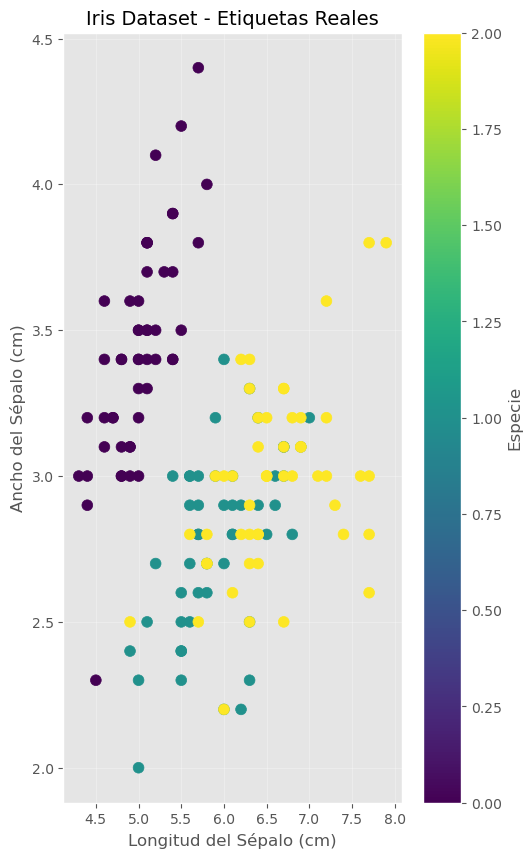

In [6]:
# Cargamos el dataset Iris
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Seleccionamos solo dos características para visualización
X_iris_2d = X_iris[:, :2]  # Longitud y ancho de sépalo

# Creamos el modelo K-Means con k=3 (sabemos que hay 3 especies)
kmeans_iris = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred_iris = kmeans_iris.fit_predict(X_iris_2d)

# Visualizamos los resultados
plt.figure(figsize=(12, 10))

# Graficamos los puntos originales
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_iris_2d[:, 0], X_iris_2d[:, 1], c=y_iris, s=60, cmap='viridis')
plt.title('Iris Dataset - Etiquetas Reales', fontsize=14)
plt.xlabel('Longitud del Sépalo (cm)', fontsize=12)
plt.ylabel('Ancho del Sépalo (cm)', fontsize=12)
plt.colorbar(scatter, label='Especie')
plt.grid(True, alpha=0.3)

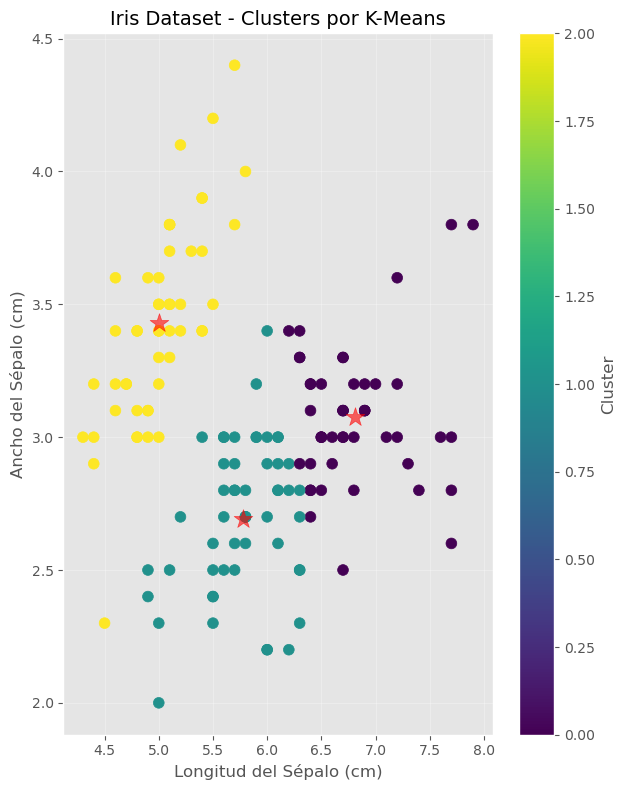

Coeficiente de silueta: 0.445


In [7]:
# Graficamos los resultados del clustering
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_iris_2d[:, 0], X_iris_2d[:, 1], c=y_pred_iris, s=60, cmap='viridis')
centroides_iris = kmeans_iris.cluster_centers_
plt.scatter(centroides_iris[:, 0], centroides_iris[:, 1], c='red', s=200, alpha=0.6, marker='*')
plt.title('Iris Dataset - Clusters por K-Means', fontsize=14)
plt.xlabel('Longitud del Sépalo (cm)', fontsize=12)
plt.ylabel('Ancho del Sépalo (cm)', fontsize=12)
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluamos la calidad del clustering
print(f"Coeficiente de silueta: {silhouette_score(X_iris_2d, y_pred_iris):.3f}")

### 7.1 Mejorando el modelo

Para garantizar un mejor resultado en el Clústering, se agregará una tercera dimensión para separar las observaciones de manera más precisa.

In [8]:
import plotly.express as px
import plotly.graph_objects as go

# Cargar el dataset Iris
iris = load_iris()
X_iris = iris.data

# pca = PCA(n_components=4)
# X_iris = pca.fit_transform(X_iris)

# Nombres de características en español
feature_names_es = [
    'Longitud del Sépalo (cm)',
    'Ancho del Sépalo (cm)',
    'Longitud del Pétalo (cm)',
    'Ancho del Pétalo (cm)'
]

# Crear el modelo K-Means con k=3 y todas las dimensiones
kmeans_iris = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred_iris = kmeans_iris.fit_predict(X_iris)
centroides_iris = kmeans_iris.cluster_centers_

# Crear la visualización 3D usando las primeras 3 dimensiones
fig = go.Figure()

# Añadimos los puntos para cada cluster
for cluster_id in range(3):
    # Filtramos los puntos de este cluster
    cluster_points = X_iris[y_pred_iris == cluster_id]

    # Añadimos los puntos al gráfico
    fig.add_trace(go.Scatter3d(
        x=cluster_points[:, 0],
        y=cluster_points[:, 1],
        z=cluster_points[:, 2],
        mode='markers',
        marker=dict(
            size=5,
            opacity=0.8,
        ),
        name=f'Cluster {cluster_id}'
    ))

# Añadimos los centroides
fig.add_trace(go.Scatter3d(
    x=centroides_iris[:, 0],
    y=centroides_iris[:, 1],
    z=centroides_iris[:, 2],
    mode='markers',
    marker=dict(
        color='red',
        size=10,
        symbol='cross',
        line=dict(
            color='black',
            width=1
        )
    ),
    name='Centroides'
))

# Configuramos el layout con nombres en español
fig.update_layout(
    title='Clusters K-Means en Dataset Iris (3D)',
    scene=dict(
        xaxis_title=feature_names_es[0],
        yaxis_title=feature_names_es[1],
        zaxis_title=feature_names_es[2],
    ),
    legend_title="Elementos",
    width=800,
    height=800,
)

# Mostrar el gráfico
fig.show()

# Evaluamos la calidad del clustering con todas las dimensiones
silhouette = silhouette_score(X_iris, y_pred_iris)
print(f"Coeficiente de silueta (usando todas las dimensiones): {silhouette:.3f}")

Coeficiente de silueta (usando todas las dimensiones): 0.553


## 9. Fortalezas y Limitaciones de K-Means

### Fortalezas:
- Simple y fácil de implementar
- Escalable a grandes conjuntos de datos
- Garantiza la convergencia
- Funciona bien con clusters esféricos de tamaño similar

### Limitaciones:
- Requiere especificar el número de clusters K de antemano
- Sensible a la inicialización de centroides
- No maneja bien clusters de forma no convexa o de diferentes tamaños
- Sensible a valores atípicos (outliers)
- Puede converger a mínimos locales

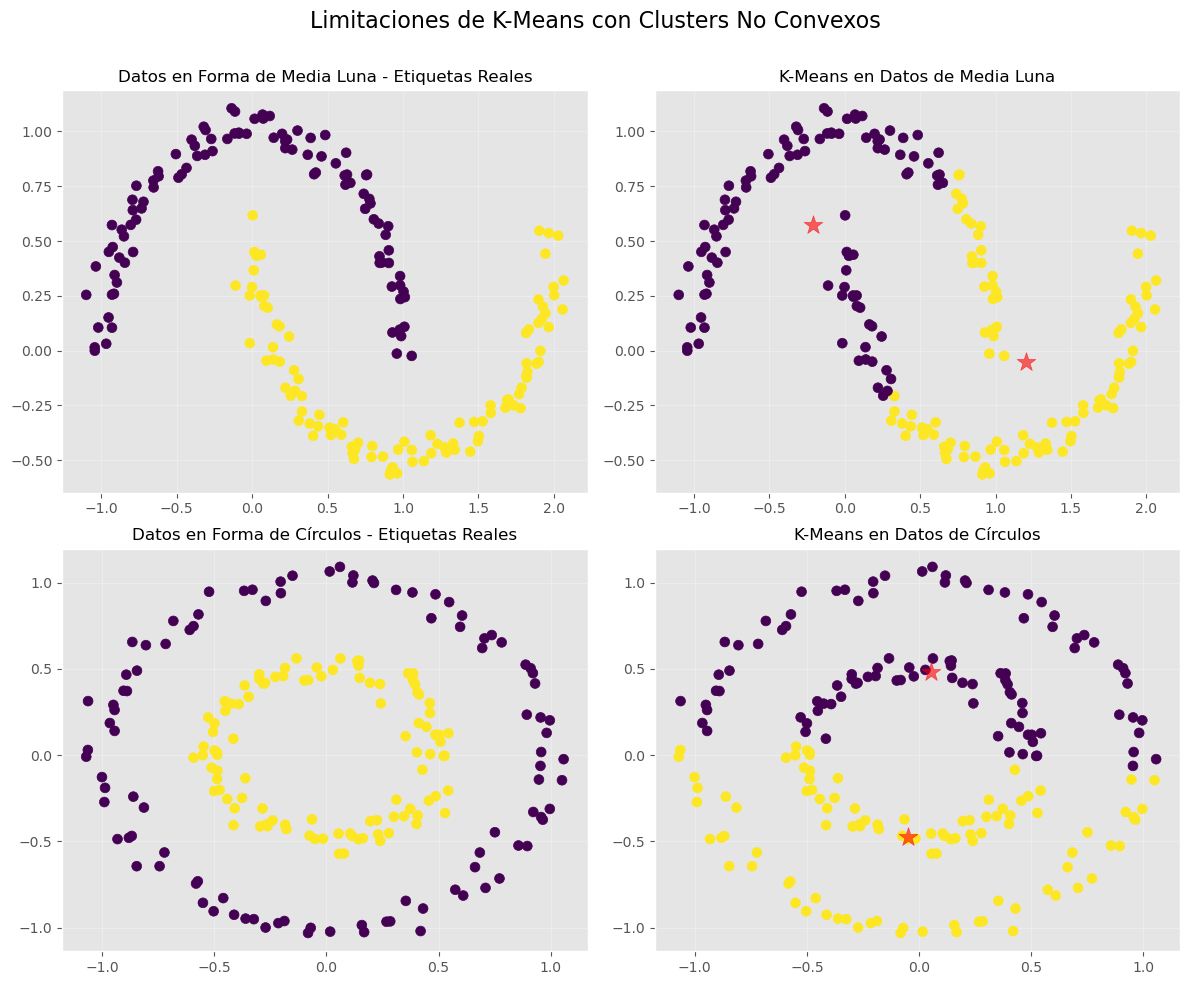

Coeficiente de silueta para datos de media luna: 0.483
Coeficiente de silueta para datos de círculos: 0.347


In [9]:
# Visualización de limitaciones de K-Means
from sklearn.datasets import make_moons, make_circles

# Crear datos en forma de media luna
X_moon, y_moon = make_moons(n_samples=200, noise=0.05, random_state=42)

# Crear datos en forma de círculos concéntricos
X_circle, y_circle = make_circles(n_samples=200, noise=0.05, factor=0.5, random_state=42)

# Aplicar K-Means a ambos conjuntos
kmeans_moon = KMeans(n_clusters=2, random_state=42)
kmeans_circle = KMeans(n_clusters=2, random_state=42)

y_pred_moon = kmeans_moon.fit_predict(X_moon)
y_pred_circle = kmeans_circle.fit_predict(X_circle)

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Datos en forma de media luna - etiquetas reales
axes[0, 0].scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, s=50, cmap='viridis')
axes[0, 0].set_title('Datos en Forma de Media Luna - Etiquetas Reales', fontsize=12)

# Datos en forma de media luna - clusters K-Means
axes[0, 1].scatter(X_moon[:, 0], X_moon[:, 1], c=y_pred_moon, s=50, cmap='viridis')
centers = kmeans_moon.cluster_centers_
axes[0, 1].scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.6, marker='*')
axes[0, 1].set_title('K-Means en Datos de Media Luna', fontsize=12)

# Datos en forma de círculos - etiquetas reales
axes[1, 0].scatter(X_circle[:, 0], X_circle[:, 1], c=y_circle, s=50, cmap='viridis')
axes[1, 0].set_title('Datos en Forma de Círculos - Etiquetas Reales', fontsize=12)

# Datos en forma de círculos - clusters K-Means
axes[1, 1].scatter(X_circle[:, 0], X_circle[:, 1], c=y_pred_circle, s=50, cmap='viridis')
centers = kmeans_circle.cluster_centers_
axes[1, 1].scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.6, marker='*')
axes[1, 1].set_title('K-Means en Datos de Círculos', fontsize=12)

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Limitaciones de K-Means con Clusters No Convexos', fontsize=16)
plt.subplots_adjust(top=0.9)
plt.show()

# Evaluación de calidad con coeficiente de silueta
print(f"Coeficiente de silueta para datos de media luna: {silhouette_score(X_moon, y_pred_moon):.3f}")
print(f"Coeficiente de silueta para datos de círculos: {silhouette_score(X_circle, y_pred_circle):.3f}")

## 10. Conclusiones

En este notebook, hemos explorado en profundidad el algoritmo K-Means:

1. Entendimos la teoría detrás del algoritmo y su funcionamiento paso a paso.
2. Aprendimos sobre la distancia euclidiana como métrica de similitud.
3. Exploramos el coeficiente de silueta como herramienta para evaluar la calidad del clustering.
4. Aplicamos K-Means a datos sintéticos y al dataset Iris.
5. Visualizamos el proceso iterativo del algoritmo.
6. Identificamos las fortalezas y limitaciones del método.

K-Means es un algoritmo potente y versátil, pero es importante entender sus limitaciones, especialmente cuando se trabaja con datos que no forman clusters convexos o de tamaño similar.

## Referencias

- Hartigan, J. A., & Wong, M. A. (1979). Algorithm AS 136: A k-means clustering algorithm. Journal of the Royal Statistical Society. Series C (Applied Statistics), 28(1), 100-108.
- Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. Journal of Computational and Applied Mathematics, 20, 53-65.
- Scikit-learn: Machine Learning in Python, Pedregosa et al., JMLR 12, pp. 2825-2830, 2011.